In [15]:
"""
Solar Resource API  - monthly averages (GHI, DNI, tilt) for a location
Docs: https://developer.nlr.gov/docs/solar/
"""

import requests
import pandas as pd
import io
import json
from typing import Optional
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ── Configuration ────────────────────────────────────────────────────────────
API_KEY   = "tTqUkXsER8iTWUXVDzM2KqHLpCgas7xkcodR4TXD"   
BASE_URL  = "https://developer.nrel.gov"

In [4]:
#Get Hourly Data
def get_hourly_nsrdb_timeseries(
    lat:         float,
    lon:         float,
    year:        str  = "2024",
    interval:    int  = 60,
    email:       str  = "ehaenel3@gatech.edu",
    attributes:  Optional[str] = None,
    leap_day:    bool = False,
    utc:         bool = False,
) -> pd.DataFrame:

    if attributes is None:
        attributes = (
            "ghi,dhi,dni,wind_speed,air_temperature,"
            "solar_zenith_angle,surface_pressure,relative_humidity"
        )

    url = f"{BASE_URL}/api/nsrdb/v2/solar/nsrdb-GOES-aggregated-v4-0-0-download.csv"

    params = {
        "api_key":      API_KEY,
        "wkt":          f"POINT({lon} {lat})",
        "names":        year,
        "interval":     interval,
        "attributes":   attributes,
        "email":        email,
        "leap_day":     str(leap_day).lower(),
        "utc":          str(utc).lower(),
        "full_name":    "Solar Data User",
        "affiliation":  "Independent",
        "reason":       "Research",
        "mailing_list": "false",
    }

    resp = requests.get(url, params=params, timeout=120)
    resp.raise_for_status()

    lines = resp.text.splitlines()

    # ── Parse metadata from rows 0 and 1 ──────────────────────────────────────
    meta_keys   = lines[0].split(",")
    meta_values = lines[1].split(",")
    meta = dict(zip(meta_keys, meta_values))

    # ── Parse data ────────────────────────────────────────────────────────────
    df = pd.read_csv(io.StringIO("\n".join(lines[2:])))

    df["datetime"] = pd.to_datetime(df[["Year", "Month", "Day", "Hour", "Minute"]])
    df = df.set_index("datetime")
    df.drop(['Hour', 'Month', 'Day', 'Minute', 'Year'], axis=1, inplace=True)

    # ── Attach metadata as columns ────────────────────────────────────────────
    desired_meta = {
        "Location_ID": meta.get("Location ID"),
        "Elevation":   meta.get("Elevation"),
    }
    for col, val in desired_meta.items():
        df[col] = val

    print(f"[NSRDB] {meta.get('City')}, {meta.get('State')} | Elev: {meta.get('Elevation')}m")
    print(f"[NSRDB] Retrieved {len(df)} rows")

    return df

In [5]:
#Get Daily Data (total)
def get_daily_nsrdb_timeseries(
    lat:         float,
    lon:         float,
    year:        str  = "2024",
    interval:    int  = 60,
    email:       str  = "ehaenel3@gatech.edu",
    attributes:  Optional[str] = None,
    leap_day:    bool = False,
    utc:         bool = False,
) -> pd.DataFrame:

    if attributes is None:
        attributes = (
            "ghi,dhi,dni,wind_speed,air_temperature,"
            "solar_zenith_angle,surface_pressure,relative_humidity"
        )

    url = f"{BASE_URL}/api/nsrdb/v2/solar/nsrdb-GOES-aggregated-v4-0-0-download.csv"

    params = {
        "api_key":      API_KEY,
        "wkt":          f"POINT({lon} {lat})",
        "names":        year,
        "interval":     interval,
        "attributes":   attributes,
        "email":        email,
        "leap_day":     str(leap_day).lower(),
        "utc":          str(utc).lower(),
        "full_name":    "Solar Data User",
        "affiliation":  "Independent",
        "reason":       "Research",
        "mailing_list": "false",
    }

    resp = requests.get(url, params=params, timeout=120)
    resp.raise_for_status()

    lines = resp.text.splitlines()

    # ── Parse metadata from rows 0 and 1 ──────────────────────────────────────
    meta_keys   = lines[0].split(",")
    meta_values = lines[1].split(",")
    meta = dict(zip(meta_keys, meta_values))

    # ── Parse data ────────────────────────────────────────────────────────────
    df = pd.read_csv(io.StringIO("\n".join(lines[2:])))

    df["datetime"] = pd.to_datetime(df[["Year", "Month", "Day", "Hour", "Minute"]])
    df = df.set_index("datetime")
    df.drop(['Hour', 'Month', 'Day', 'Minute', 'Year'], axis=1, inplace=True)

    # ── Aggregate to daily ────────────────────────────────────────────────────
    sum_cols  = [c for c in ["GHI", "DHI", "DNI"] if c in df.columns]
    mean_cols = [c for c in ["Wind Speed", "Temperature", "Solar Zenith Angle",
                              "Pressure", "Relative Humidity"] if c in df.columns]
    agg = {}
    for c in sum_cols:
        agg[c] = pd.NamedAgg(column=c, aggfunc="sum")
    for c in mean_cols:
        agg[c] = pd.NamedAgg(column=c, aggfunc="mean")

    df = df.resample("D").agg(**agg)

    # ── Attach metadata as columns ────────────────────────────────────────────
    desired_meta = {
        "Location_ID": meta.get("Location ID"),
        "Elevation":   meta.get("Elevation"),
    }
    for col, val in desired_meta.items():
        df[col] = val

    print(f"[NSRDB] {meta.get('City')}, {meta.get('State')} | Elev: {meta.get('Elevation')}m")
    print(f"[NSRDB] Retrieved {len(df)} rows")

    return df

In [ ]:
#__________________Date cleaning - No Updates Needed_______________________
# Check for null values - decided not to drop any 
print("\nNull values:")
print(irradiance_df.isnull().sum())

# Outlier detection (z-score per city)
print("\nOutliers (|z| > 4) per city:")
for city in irradiance_df["City"].unique():
    mask  = irradiance_df["City"] == city
    z     = np.abs(stats.zscore(irradiance_df.loc[mask, "GHI"].dropna()))
    n_out = (z > 4).sum()
    print(f"  {city}: {n_out} GHI outliers")

# Continuity check — missing dates per city 
print("\nMissing dates per city:")
for city in irradiance_df["City"].unique():
    city_df     = irradiance_df[irradiance_df["City"] == city]
    full_range  = pd.date_range(city_df.index.min(), city_df.index.max(), freq="D")
    missing_dates = full_range.difference(city_df.index)
    print(f"  {city}: {len(missing_dates)} missing days")


Null values:
GHI                   0
DHI                   0
DNI                   0
Wind Speed            7
Temperature           7
Solar Zenith Angle    7
Pressure              7
Relative Humidity     7
Location_ID           0
Elevation             0
City                  0
dtype: int64

Outliers (|z| > 4) per city:
  Phoenix: 0 GHI outliers
  Los Angeles: 0 GHI outliers
  Atlanta: 0 GHI outliers
  Chicago: 0 GHI outliers
  Boston: 0 GHI outliers
  Denver: 0 GHI outliers
  Seattle: 0 GHI outliers


In [23]:
def run_eda(df: pd.DataFrame):
    # ── 2a. Summary stats ─────────────────────────────────────────────────────
    print("=== SUMMARY STATISTICS ===")
    print(df.groupby("City")[["GHI", "DNI", "DHI", "Temperature"]].describe().round(1))

    numeric_cols = ["GHI", "DHI", "DNI", "Temperature",
                    "Wind Speed", "Pressure", "Relative Humidity"]
    numeric_cols = [c for c in numeric_cols if c in df.columns]

    fig, axes = plt.subplots(3, 3, figsize=(16, 14))
    fig.suptitle("NSRDB Daily Irradiance EDA", fontsize=16, fontweight="bold")
    axes = axes.flatten()
    plot_idx = 0

    # ── 2b. Annual GHI by city (box plot) ─────────────────────────────────────
    ax = axes[plot_idx]; plot_idx += 1
    city_order = df.groupby("City")["GHI"].median().sort_values(ascending=False).index.tolist()
    sns.boxplot(data=df, x="City", y="GHI", order=city_order, ax=ax)
    ax.set_title("Daily GHI Distribution by City")
    ax.set_xlabel(""); ax.set_ylabel("GHI (Wh/m²)")
    plt.sca(ax); plt.xticks(rotation=30, ha="right")

    # ── 2c. Monthly seasonality per city ──────────────────────────────────────
    ax = axes[plot_idx]; plot_idx += 1
    monthly = df.groupby(["City", df.index.month])["GHI"].mean().unstack(level=0)
    monthly.plot(ax=ax, marker="o", linewidth=1.5)
    ax.set_title("Monthly Avg Daily GHI by City")
    ax.set_xlabel("Month"); ax.set_ylabel("Avg GHI (Wh/m²)")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"])
    ax.legend(fontsize=7)

    # ── 2d. Year-over-year trend ───────────────────────────────────────────────
    ax = axes[plot_idx]; plot_idx += 1
    yearly = df.groupby(["City", df.index.year])["GHI"].sum().unstack(level=0) / 1000
    yearly.plot(kind="bar", ax=ax)
    ax.set_title("Annual GHI by City (MWh/m²)")
    ax.set_xlabel("Year"); ax.set_ylabel("Total GHI (MWh/m²)")
    ax.legend(fontsize=7); plt.sca(ax); plt.xticks(rotation=0)

    # ── 2e. Correlation heatmap ───────────────────────────────────────────────
    ax = axes[plot_idx]; plot_idx += 1
    corr = df[numeric_cols].corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
                center=0, ax=ax, annot_kws={"size": 8})
    ax.set_title("Feature Correlation Matrix")

    # ── 2f. GHI distribution (histogram per city) ─────────────────────────────
    ax = axes[plot_idx]; plot_idx += 1
    for city in df["City"].unique():
        df[df["City"] == city]["GHI"].hist(
            ax=ax, bins=50, alpha=0.5, label=city, density=True)
    ax.set_title("GHI Distribution by City")
    ax.set_xlabel("GHI (Wh/m²)"); ax.set_ylabel("Density")
    ax.legend(fontsize=7)

    # ── 2g. GHI vs Temperature scatter ────────────────────────────────────────
    ax = axes[plot_idx]; plot_idx += 1
    for city in df["City"].unique():
        sub = df[df["City"] == city]
        ax.scatter(sub["Temperature"], sub["GHI"], alpha=0.3, s=5, label=city)
    ax.set_title("GHI vs Temperature")
    ax.set_xlabel("Temperature (°C)"); ax.set_ylabel("GHI (Wh/m²)")
    ax.legend(fontsize=7, markerscale=3)

    # ── 2h. Rolling 30-day GHI for each city ──────────────────────────────────
    ax = axes[plot_idx]; plot_idx += 1
    for city in df["City"].unique():
        sub = df[df["City"] == city]["GHI"].rolling(30).mean()
        ax.plot(sub.index, sub.values, label=city, linewidth=1)
    ax.set_title("30-Day Rolling Avg GHI")
    ax.set_xlabel("Date"); ax.set_ylabel("GHI (Wh/m²)")
    ax.legend(fontsize=7)

    # ── 2i. GHI by day of year (avg across all years) ─────────────────────────
    ax = axes[plot_idx]; plot_idx += 1
    doy = df.groupby(["City", df.index.dayofyear])["GHI"].mean().unstack(level=0)
    doy.plot(ax=ax, linewidth=1, alpha=0.8)
    ax.set_title("Avg GHI by Day of Year")
    ax.set_xlabel("Day of Year"); ax.set_ylabel("Avg GHI (Wh/m²)")
    ax.legend(fontsize=7)

    # ── 2j. Missing data heatmap per city ─────────────────────────────────────
    ax = axes[plot_idx]; plot_idx += 1
    missing_pct = df.groupby("City")[numeric_cols].apply(
        lambda x: x.isnull().mean() * 100)
    sns.heatmap(missing_pct, annot=True, fmt=".1f", cmap="Reds",
                ax=ax, annot_kws={"size": 8})
    ax.set_title("Missing Data % by City")

    plt.tight_layout()
    plt.savefig("nsrdb_eda.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("\nEDA saved to nsrdb_eda.png")

=== SUMMARY STATISTICS ===
                GHI                                                       \
              count    mean     std  min     25%     50%     75%     max   
City                                                                       
Atlanta      1461.0  4680.7  2136.8  0.0  3226.0  4826.0  6381.0  8803.0   
Boston       1461.0  3937.4  2316.0  0.0  2029.0  3650.0  5919.0  8847.0   
Chicago      1461.0  3888.1  2430.2  0.0  1752.0  3643.0  5993.0  9017.0   
Denver       1461.0  4907.3  2190.1  0.0  3010.0  4874.0  6766.0  9423.0   
Los Angeles  1461.0  5387.6  2142.6  0.0  3662.0  5439.0  7376.0  8934.0   
Phoenix      1461.0  5811.5  2039.6  0.0  4085.0  5875.0  7665.0  9235.0   
Seattle      1461.0  3646.2  2572.2  0.0  1311.0  3128.0  5873.0  8833.0   

                DNI          ...     DHI         Temperature              \
              count    mean  ...     75%     max       count  mean   std   
City                         ...                            

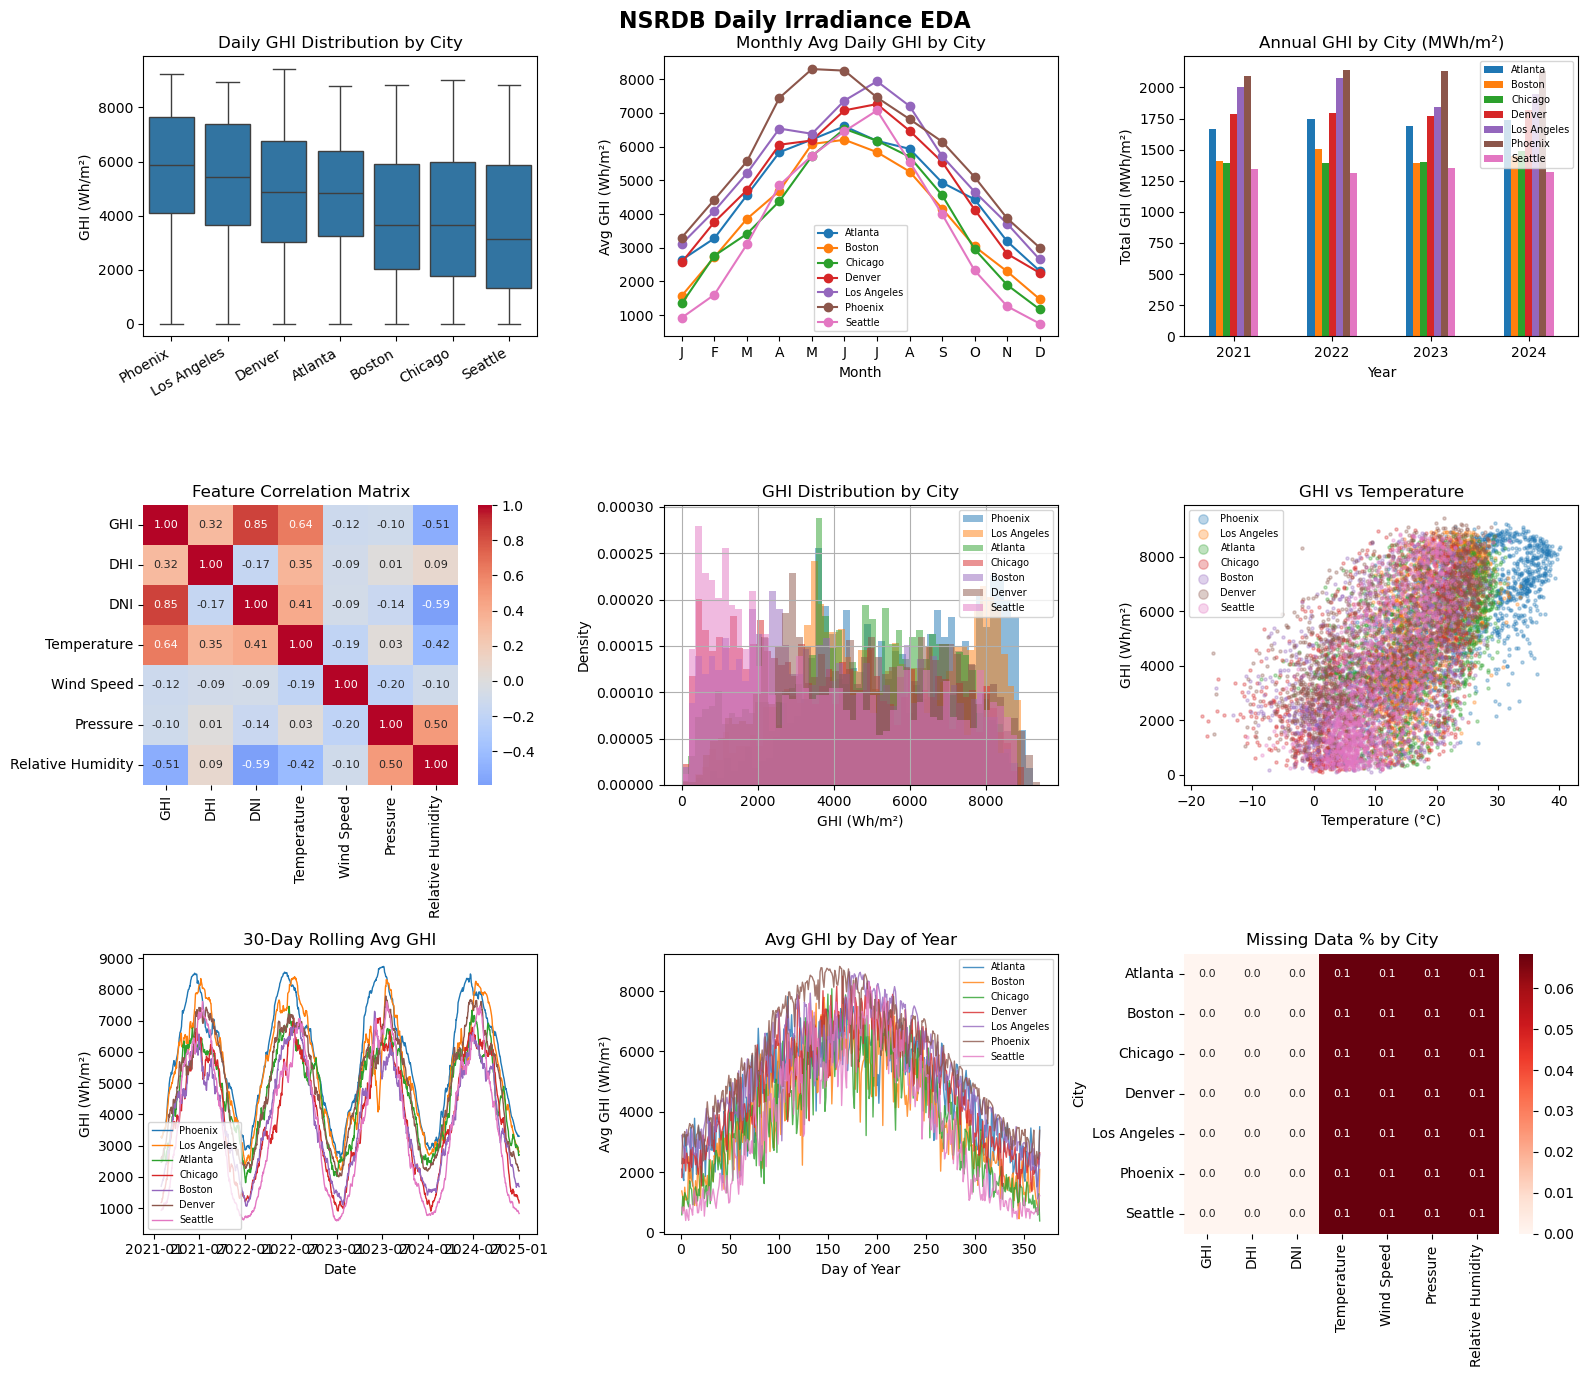


EDA saved to nsrdb_eda.png


In [24]:
if __name__ == "__main__":

    cities = [
        ('Phoenix',       33.4484,  -112.0740),   # Desert Southwest
        ('Los Angeles',   34.0522,  -118.2437),   # Pacific Coast
        ('Atlanta',       33.7490,   -84.3880),   # Southeast
        ('Chicago',       41.8781,   -87.6298),   # Midwest
        ('Boston',        42.3601,   -71.0589),   # Northeast
        ('Denver',        39.7392,  -104.9903),   # Mountain
        ('Seattle',       47.6062,  -122.3321),   # Pacific Northwest
    ]

    years = ["2021", "2022", "2023", "2024"]
    
    # --- Pull & cache data --------------------------------
    # frames = []
    # for name, lat, lon in cities:
    #     for year in years:
    #         print(f"Pulling {name} {year}...")
    #         df = get_daily_nsrdb_timeseries(lat=lat, lon=lon, year=year)
    #         df["City"] = name
    #         frames.append(df)
    # irradiance_df = pd.concat(frames)
    # irradiance_df.to_parquet("irradiance_2021_2024.parquet")

    # --- Load from cache -------------------------------------------------------
    irradiance_df = pd.read_parquet("irradiance_2021_2024.parquet")
    run_eda(irradiance_df)